In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/data/raw/Données_Marchés_publics_2024.xlsx", sheet_name='Feuil2')
df.head()

,ident,Type_de_centre,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,MinCA19,Conformité de déclaration de marchés en 2019,Conformité de déclaration de marchés en 2020,Conformité de déclaration de marchés en 2021,...,Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024,MontantMP24,DSF23,SBTP,SERM,SFBME,SPSOE,Actif2024,STLM,Ecart24(Target)
0,1,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,...,Bonne déclaration,1603333,Oui,Oui,Oui,Oui,Oui,Oui,Oui,-1.603333e+06
1,2,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,...,Mauvaise déclaration,1788690,Oui,Oui,Non,Oui,Oui,Oui,Non,5.976523e+09
2,3,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,88743200,Oui,Non,Non,Oui,Non,Oui,Non,7.260409e+09
3,4,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,14800000,Oui,Oui,Non,Non,Non,Oui,Non,3.240741e+09
4,5,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,12703175,Oui,Non,Non,Non,Non,Oui,Oui,3.652986e+09


In [3]:
df.columns

Index(['ident', 'Type_de_centre', 'Regime', 'Persojuri',
       'gctax (groupe de compte de gestion des contribuables)',
       'Type de déclarant des MP dans les DSF', 'MinCA19',
       'Conformité de déclaration de marchés en 2019',
       'Conformité de déclaration de marchés en 2020',
       'Conformité de déclaration de marchés en 2021',
       'Conformité de déclaration de marchés en 2022',
       'Conformité de déclaration de marchés en 2023', 'MinCA20', 'MinCA21',
       'MinCA22', 'MinCA23', 'MinCA19_23', 'Nbprestation_marchés',
       'Typedemarché',
       'Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024',
       'MontantMP24', 'DSF23', 'SBTP', 'SERM', 'SFBME', 'SPSOE', 'Actif2024',
       'STLM', 'Ecart24(Target)'],
      dtype='object')

## DELTCA
- On a 4107 valeurs égales à 0
- On a 1057 valeurs inférieures à 0
- On a 6634 > 0

In [4]:
df.drop(['Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024', 'ident', 'Type_de_centre',
           'Conformité de déclaration de marchés en 2019', 'Conformité de déclaration de marchés en 2020',
           'Conformité de déclaration de marchés en 2021', 'Conformité de déclaration de marchés en 2022',
           'SBTP', 'SERM', 'SFBME', 'SPSOE', 'STLM',
           'MinCA19', 'MinCA20', 'MinCA21', 'MinCA22', 'MinCA19_23'], axis=1, inplace=True)

## clustering pour déterminer le nombre de segments optimal

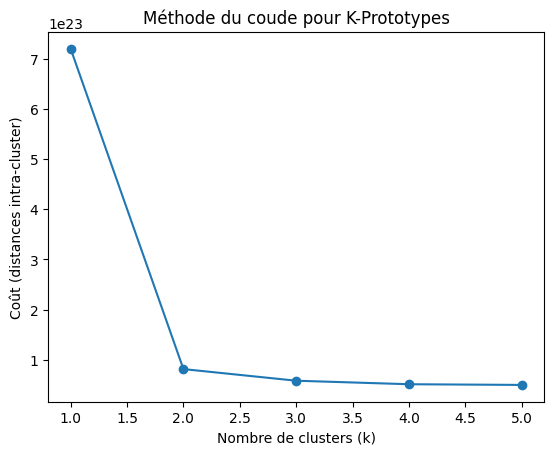

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes


# Colonnes catégorielles
categorical_cols = df.select_dtypes('object')
categorical_idx = [df.columns.get_loc(c) for c in categorical_cols]

# Conversion en numpy
X = df.to_numpy()

# Méthode du coude
costs = []
K = range(1, 6)  # on teste entre 1 et 7 clusters

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)

# Tracer la courbe du coude
plt.plot(K, costs, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Coût (distances intra-cluster)")
plt.title("Méthode du coude pour K-Prototypes")
plt.savefig('Resultats_segmentation.png')
plt.show()
